In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import sys, os
sys.path.append('/content/drive/MyDrive/Colab Notebooks/FreshRetailNet Demand Forecasting/src')
import numpy as np, pandas as pd, lightgbm as lgb
import config as cf, data, predictions, evaluate

In [3]:
# results charts setup
import pandas as pd, matplotlib.pyplot as plt

RAW, REC, GREY = '#1f77b4', '#ff7f0e', '#8c8c8c'
FIGDIR = f'{cf.PROJECT}/figures'

r = pd.read_csv(f'{cf.EVALUATION}/results_test_full.csv')
wape  = r.pivot(index='model', columns='input', values='WAPE').sort_values('recovered')
wpe   = r.pivot(index='model', columns='input', values='WPE').loc[wape.index]
rmsse = r.pivot(index='model', columns='input', values='RMSSE').loc[wape.index]

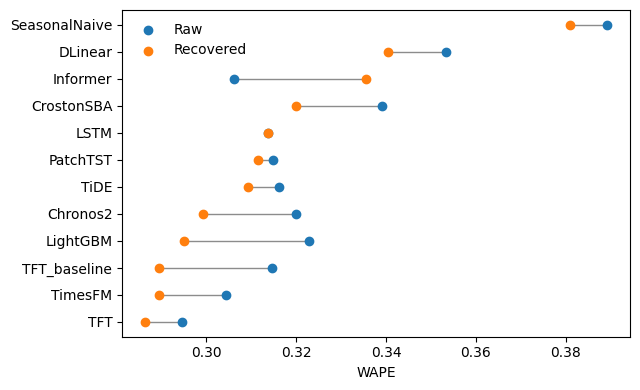

In [4]:
# WAPE by model, both pipelines
y = range(len(wape))
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hlines(y, wape['raw'], wape['recovered'], color=GREY, linewidth=1)
ax.scatter(wape['raw'], y, color=RAW, label='Raw', zorder=3)
ax.scatter(wape['recovered'], y, color=REC, label='Recovered', zorder=3)
ax.set_yticks(list(y)); ax.set_yticklabels(wape.index)
ax.set_xlabel('WAPE')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wape_by_model.png', dpi=300)
plt.show()

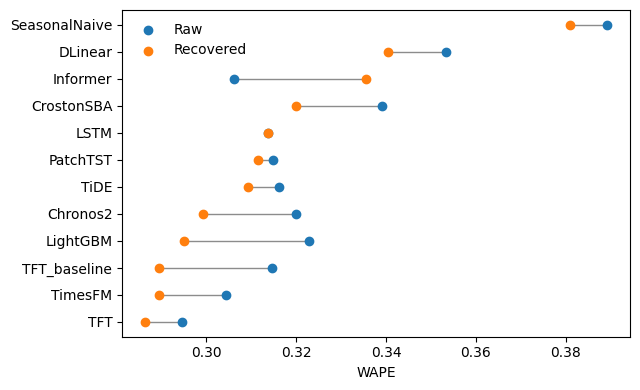

In [ ]:
# WAPE by model, both pipelines
y = range(len(wape))
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hlines(y, wape['raw'], wape['recovered'], color=GREY, linewidth=1)
ax.scatter(wape['raw'], y, color=RAW, label='Raw', zorder=3)
ax.scatter(wape['recovered'], y, color=REC, label='Recovered', zorder=3)
ax.set_yticks(list(y)); ax.set_yticklabels(wape.index)
ax.set_xlabel('WAPE')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wape_by_model.png', dpi=300)
plt.show()

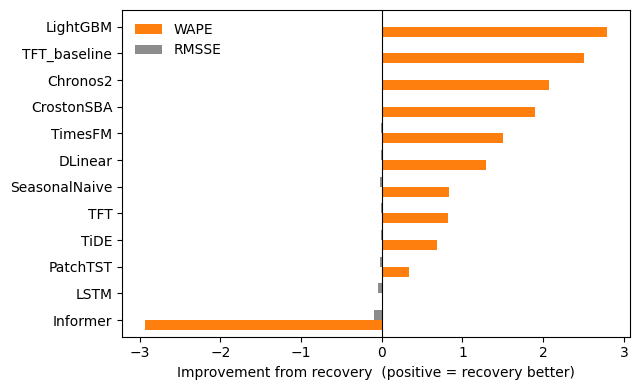

In [ ]:
# improvement from recovery, by metric
gain = pd.DataFrame({'WAPE': wape['raw'] - wape['recovered'],
                     'RMSSE': rmsse['raw'] - rmsse['recovered']}).sort_values('WAPE')

ax = gain.plot(kind='barh', figsize=(6.5, 4), color=[REC, GREY], width=0.75)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Improvement from recovery  (positive = recovery better)')
ax.set_ylabel('')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_metric_disagreement.png', dpi=300)
plt.show()

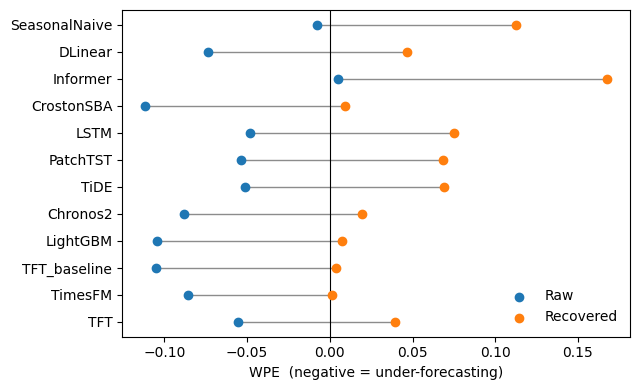

In [ ]:
# WPE by model, both pipelines
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hlines(y, wpe['raw'], wpe['recovered'], color=GREY, linewidth=1)
ax.scatter(wpe['raw'], y, color=RAW, label='Raw', zorder=3)
ax.scatter(wpe['recovered'], y, color=REC, label='Recovered', zorder=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(list(y)); ax.set_yticklabels(wpe.index)
ax.set_xlabel('WPE  (negative = under-forecasting)')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wpe_by_model.png', dpi=300)
plt.show()

In [ ]:
#setup
import pandas as pd, matplotlib.pyplot as plt

RAW, REC, GREY = '#1f77b4', '#ff7f0e', '#8c8c8c'
FIGDIR = f'{cf.PROJECT}/figures'

r = pd.read_csv(f'{cf.EVALUATION}/results_test_full.csv')
wape  = r.pivot(index='model', columns='input', values='WAPE') * 100
rmsse = r.pivot(index='model', columns='input', values='RMSSE')

ORDER = wape.sort_values('recovered', ascending=False).index    # best at top
wape, rmsse = wape.loc[ORDER], rmsse.loc[ORDER]

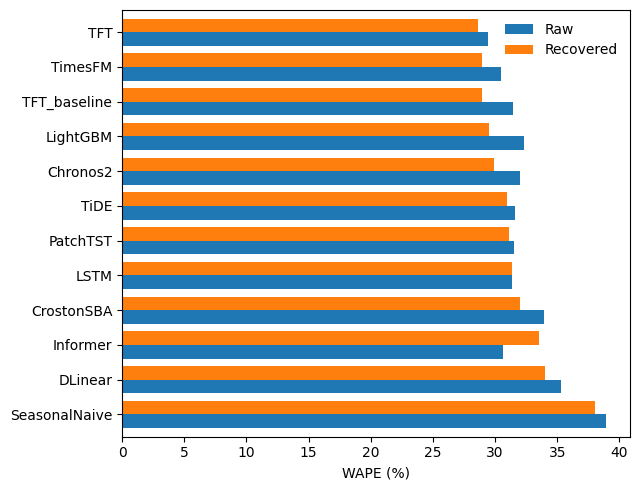

In [ ]:
#WAPE by model, raw vs recovered
ax = wape[['raw', 'recovered']].plot(kind='barh', figsize=(6.5, 5),
                                     color=[RAW, REC], width=0.78)
ax.set_xlabel('WAPE (%)')
ax.set_ylabel('')
ax.legend(['Raw', 'Recovered'], frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wape_by_model.png', dpi=300)
plt.show()

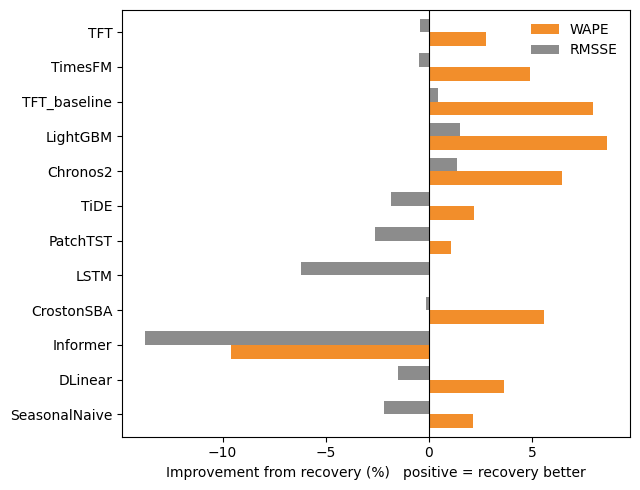

In [ ]:
#improvement from recovery, WAPE and RMSSE
REC = '#F28E2B'
gain = pd.DataFrame({
    'WAPE':  (wape['raw']  - wape['recovered'])  / wape['raw']  * 100,
    'RMSSE': (rmsse['raw'] - rmsse['recovered']) / rmsse['raw'] * 100,
}).loc[ORDER]

ax = gain.plot(kind='barh', figsize=(6.5, 5), color=[REC, GREY], width=0.78)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Improvement from recovery (%)   positive = recovery better')
ax.set_ylabel('')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_recovery_improvement.png', dpi=300)
plt.show()

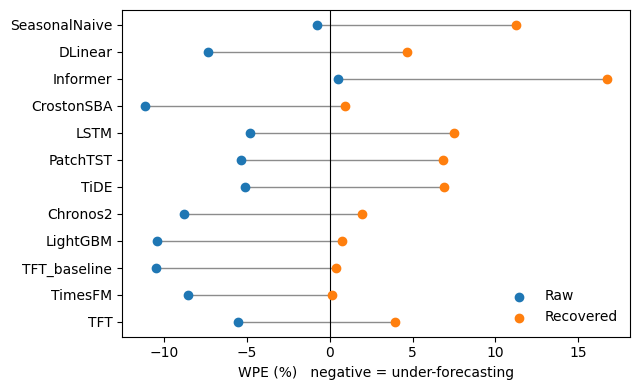

In [ ]:
#WPE by model, both pipelines
wpe100 = wpe * 100
y = range(len(wpe100))

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hlines(y, wpe100['raw'], wpe100['recovered'], color=GREY, linewidth=1)
ax.scatter(wpe100['raw'], y, color=RAW, label='Raw', zorder=3)
ax.scatter(wpe100['recovered'], y, color=REC, label='Recovered', zorder=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(list(y)); ax.set_yticklabels(wpe100.index)
ax.set_xlabel('WPE (%)   negative = under-forecasting')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wpe_by_model.png', dpi=300)
plt.show()

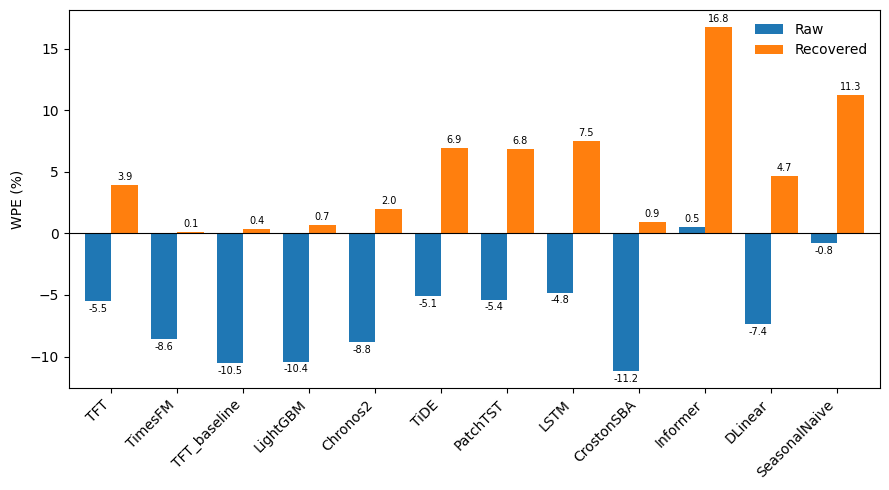

In [ ]:
#WPE by model, column chart with values
wpe100 = (wpe * 100).rename(columns={'raw': 'Raw', 'recovered': 'Recovered'})

ax = wpe100[['Raw', 'Recovered']].plot(kind='bar', figsize=(9, 5),
                                       color=[RAW, REC], width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)

ax.set_ylabel('WPE (%)')
ax.set_xlabel('')
ax.legend(frameon=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wpe_by_model.png', dpi=300)
plt.show()

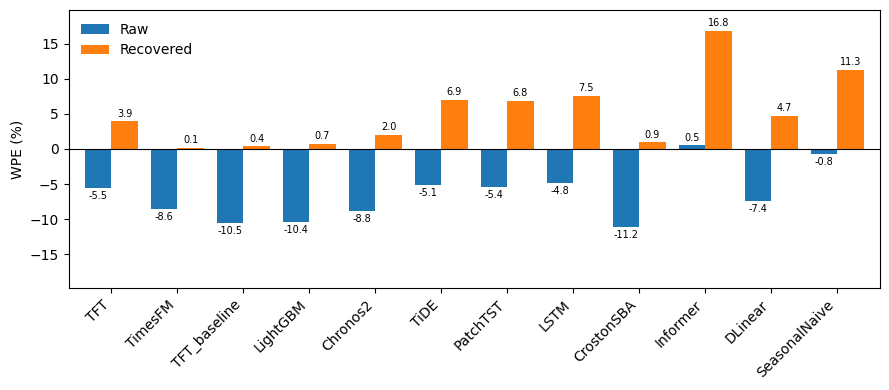

In [ ]:
#WPE by model, column chart with values
wpe100 = (wpe * 100).rename(columns={'raw': 'Raw', 'recovered': 'Recovered'})

ax = wpe100[['Raw', 'Recovered']].plot(kind='bar', figsize=(9, 4),
                                       color=[RAW, REC], width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)

lim = wpe100.abs().max().max() * 1.18       # symmetric about zero, room for labels
ax.set_ylim(-lim, lim)

ax.set_ylabel('WPE (%)')
ax.set_xlabel('')
ax.legend(frameon=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wpe_by_model.png', dpi=300)
plt.show()

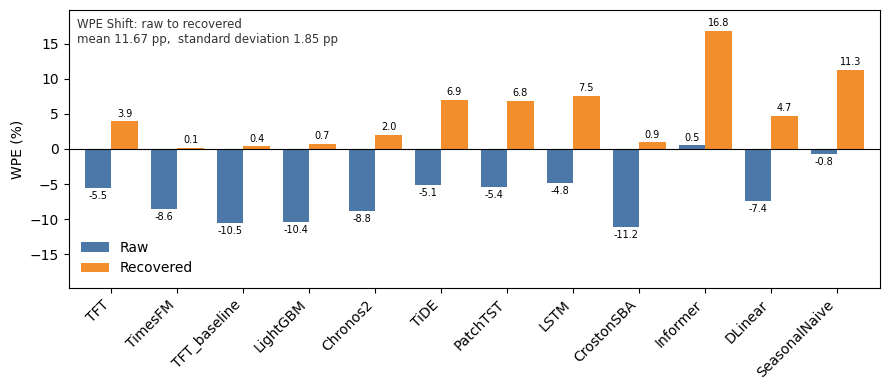

In [ ]:
# WPE by model, column chart with values

RAW = '#4C78A8'  #1f77b4'     # recorded sales
REC = '#F28E2B'
wpe100 = (wpe * 100).rename(columns={'raw': 'Raw', 'recovered': 'Recovered'})

shift = wpe100['Recovered'] - wpe100['Raw']        # added
m, s = shift.mean(), shift.std()                   # added

ax = wpe100[['Raw', 'Recovered']].plot(kind='bar', figsize=(9, 4),
                                       color=[RAW, REC], width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)

lim = wpe100.abs().max().max() * 1.18       # symmetric about zero, room for labels
ax.set_ylim(-lim, lim)

ax.text(0.01, 0.97,                                # added
        f'WPE Shift: raw to recovered\nmean {m:.2f} pp,  standard deviation {s:.2f} pp',
        transform=ax.transAxes, fontsize=8.5, va='top', ha='left',
        color='#333333')


ax.set_ylabel('WPE (%)')
ax.set_xlabel('')
ax.legend(frameon=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wpe_by_model.png', dpi=300)
plt.show()

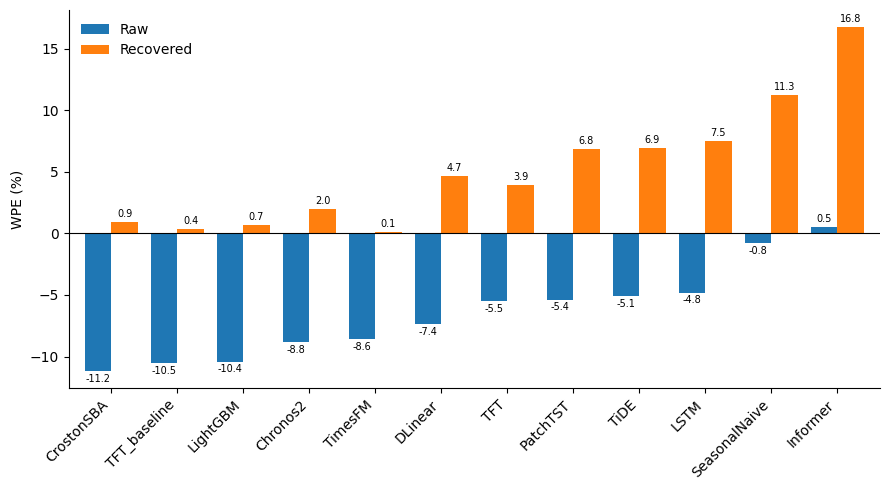

mean shift 11.67   sd 1.85


In [ ]:
# Cell N — WPE by model, sorted by raw WPE so the uniform shift is visible
wpe100 = (wpe * 100).rename(columns={'raw': 'Raw', 'recovered': 'Recovered'})
wpe100 = wpe100.sort_values('Raw')          # <- the change that matters

ax = wpe100[['Raw', 'Recovered']].plot(kind='bar', figsize=(9, 5),
                                       color=[RAW, REC], width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)

ax.set_ylabel('WPE (%)')
ax.set_xlabel('')
ax.grid(False)
for s in ('top', 'right'):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wpe_by_model.png', dpi=300)
plt.show()

print('mean shift', round((wpe100['Recovered'] - wpe100['Raw']).mean(), 2),
      '  sd', round((wpe100['Recovered'] - wpe100['Raw']).std(), 2))

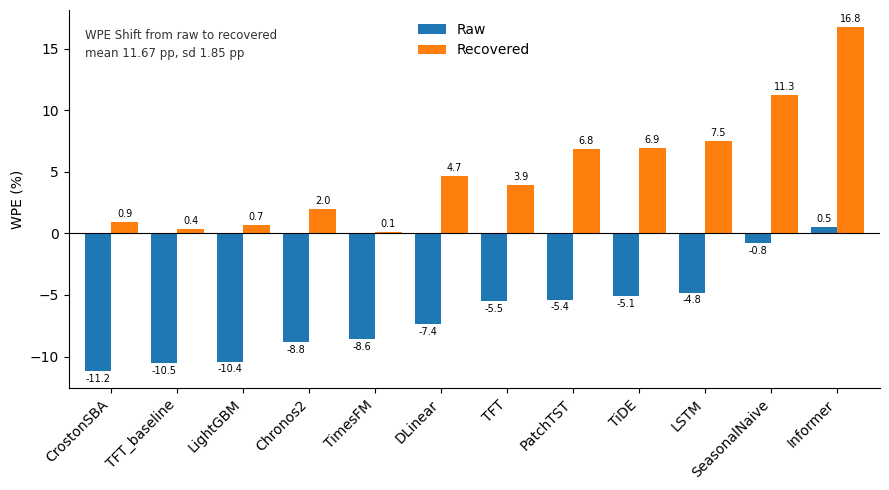

In [ ]:
# Cell N — WPE by model, sorted by raw WPE, with the shift summarised
wpe100 = (wpe * 100).rename(columns={'raw': 'Raw', 'recovered': 'Recovered'})
wpe100 = wpe100.sort_values('Raw')

shift = wpe100['Recovered'] - wpe100['Raw']
m, s = shift.mean(), shift.std()

ax = wpe100[['Raw', 'Recovered']].plot(kind='bar', figsize=(9, 5),
                                       color=[RAW, REC], width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.1f', fontsize=7, padding=2)

ax.text(0.02, 0.95,
        f'WPE Shift from raw to recovered\nmean {m:.2f} pp, sd {s:.2f} pp',
        transform=ax.transAxes, fontsize=8.5, va='top', ha='left',
        color='#333333', linespacing=1.5)

ax.set_ylabel('WPE (%)')
ax.set_xlabel('')
ax.grid(False)
for sp in ('top', 'right'):
    ax.spines[sp].set_visible(False)
ax.legend(frameon=False, loc='upper center')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig_wpe_by_model.png', dpi=300)
plt.show()

In [ ]:
# Cell — accuracy by forecast horizon
import evaluate as ev, config as cf

m = ev.load_predictions('test').merge(ev.truth('test'),
        on=['store_id', 'product_id', 'dt'], how='inner')
m['h'] = (pd.to_datetime(m['dt']) - pd.Timestamp(cf.TEST_START)).dt.days + 1
m['dow'] = pd.to_datetime(m['dt']).dt.day_name().str[:3]

def wape(g):
    return (g['prediction'] - g['sale_amount']).abs().sum() / g['sale_amount'].sum()

tab = (m[m.model.isin(['TFT', 'LightGBM', 'TimesFM'])]
         .groupby(['model', 'input', 'h'])
         .apply(wape, include_groups=False)
         .unstack('h') * 100).round(2)

print(m.groupby('h')['dow'].first().to_string())
print()
print(tab.to_string())

h
1    Wed
2    Thu
3    Fri
4    Sat
5    Sun
6    Mon
7    Tue

h                       1      2      3      4      5      6      7
model    input                                                     
LightGBM raw        27.51  28.98  29.92  30.31  37.12  35.56  37.80
         recovered  27.63  28.45  28.92  28.80  31.99  30.27  30.67
TFT      raw        28.27  28.84  29.57  28.83  29.86  29.90  31.41
         recovered  27.53  27.85  28.80  28.71  29.58  28.76  29.26
TimesFM  raw        28.52  29.20  29.88  30.40  33.16  30.21  31.63
         recovered  27.99  28.16  28.78  29.05  30.56  28.48  29.49
